In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.impute import SimpleImputer
df = pd.read_csv(r"C:\Users\SNEHALATA ROUT\Downloads\collections.postmortem_tissue_core.rnaseq_metadata.csv")

In [4]:
import re
import numpy as np
import pandas as pd

MONTH = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
         "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}

MISSING = {"", "NA", "N/A", "N/D", "ND", "Unknown", "-9999", None}

def parse_repeat_pair(x):
    s = None if x is None else str(x).strip()
    if s in MISSING:
        return (np.nan, np.nan, "missing")

    # a/b
    m = re.match(r"^(\d+)\s*/\s*(\d+)$", s)
    if m:
        return (int(m.group(1)), int(m.group(2)), "ok")

    # dd-MMM  -> (dd, month)
    m = re.match(r"^(\d{1,2})-([A-Za-z]{3})$", s)
    if m and m.group(2) in MONTH:
        return (int(m.group(1)), MONTH[m.group(2)], "excel_artifact")

    # MMM-dd  -> (month, dd)  (covers MMM-yy artifacts too)
    m = re.match(r"^([A-Za-z]{3})-(\d{1,2})$", s)
    if m and m.group(1) in MONTH:
        return (MONTH[m.group(1)], int(m.group(2)), "excel_artifact")

    return (np.nan, np.nan, "unparsed")

def add_repeat_features(df, raw_col, prefix):
    a1, a2, st = zip(*(parse_repeat_pair(v) for v in df[raw_col].tolist()))
    df[f"{prefix}_a1"] = a1
    df[f"{prefix}_a2"] = a2
    df[f"{prefix}_max"] = df[[f"{prefix}_a1", f"{prefix}_a2"]].max(axis=1)
    df[f"{prefix}_mean"] = df[[f"{prefix}_a1", f"{prefix}_a2"]].mean(axis=1)
    df[f"{prefix}_parse_status"] = st
    df[f"{prefix}_is_missing"] = (df[f"{prefix}_parse_status"] == "missing").astype(int)
    return df

df = add_repeat_features(df, "C 9 Repeat Size", "C9")
df = add_repeat_features(df, "Atxn 2 Repeat Size", "ATXN2")

# GeneReviews C9 categories: 2–24 normal, 25–60 uncertain, >=61 pathogenic
bins = [-np.inf, 24, 60, np.inf]
labels = ["normal", "uncertain", "pathogenic"]
df["C9_category"] = pd.cut(df["C9_max"], bins=bins, labels=labels)

# ATXN2 thresholds: >=27 (foundational), >=31 (large cohort)
df["ATXN2_ge_27"] = (df["ATXN2_max"] >= 27).astype(int)
df["ATXN2_ge_31"] = (df["ATXN2_max"] >= 31).astype(int)
df["ATXN2_ge_34"] = (df["ATXN2_max"] >= 34).astype(int)  # QC/SCA2-like


In [9]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from xgboost import XGBClassifier

MISSING_TOKENS = {"ND", "N/D", "N/A", "NA", "Unknown", "UNKNOWN", "", "-9999"}

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class CleanNumericTokens(BaseEstimator, TransformerMixin):
    """
    Replace missing sentinel tokens with NaN and coerce to numeric.
    Clone-safe: __init__ stores parameters without modification.
    """
    def __init__(self, missing_tokens=("ND", "N/D", "N/A", "NA", "Unknown", "UNKNOWN", "", "-9999")):
        self.missing_tokens = missing_tokens  # do NOT cast/copy here

    def fit(self, X, y=None):
        # Derived attribute (safe to compute here)
        self.missing_tokens_set_ = set(self.missing_tokens)
        return self

    def transform(self, X):
        Xdf = pd.DataFrame(X).copy()
        Xdf = Xdf.replace(list(self.missing_tokens_set_), np.nan)
        for c in Xdf.columns:
            Xdf[c] = pd.to_numeric(Xdf[c], errors="coerce")
        return Xdf.to_numpy()


num_pipe = Pipeline(steps=[
    ("clean", CleanNumericTokens()),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True))
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

xgb = XGBClassifier(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model = Pipeline(steps=[("prep", preprocess), ("clf", xgb)])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


In [10]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

roc, pr, brier = [], [], []
base_pr = y.mean()

for tr, te in cv.split(X, y, groups):
    model.fit(X.iloc[tr], y[tr])
    # Calibrate on train via inner CV to avoid test leakage
    calib = CalibratedClassifierCV(model, method="isotonic", cv=3)
    calib.fit(X.iloc[tr], y[tr])

    p = calib.predict_proba(X.iloc[te])[:, 1]
    roc.append(roc_auc_score(y[te], p))
    pr.append(average_precision_score(y[te], p))
    brier.append(brier_score_loss(y[te], p))

print("ROC-AUC:", np.mean(roc))
print("PR-AUC:", np.mean(pr), "baseline PR:", base_pr)
print("Brier:", np.mean(brier))


ROC-AUC: 0.7965343693196874
PR-AUC: 0.9536426572560497 baseline PR: 0.8780380026513478
Brier: 0.08567931596721663


In [11]:
def with_feature_mask(dfX, drop_cols):
    keep = [c for c in dfX.columns if c not in drop_cols]
    return dfX[keep]

X_full = X.copy()

X_no_c9 = with_feature_mask(X_full, ["C 9 Orf 72 Repeat Expansion", "C9_max", "C9_category"])
X_c9_only = X_full[["C 9 Orf 72 Repeat Expansion", "C9_max", "C9_category"]]


In [12]:
from sklearn.metrics.pairwise import euclidean_distances

# Suppose you trained a model and can obtain transformed features:
Z = preprocess.fit_transform(X_full)  # or from a learned embedding

is_als = (y == 1)
is_ctrl = (df["Subject Group"].astype(str).str.contains("Control", case=False, na=False).values)

proto_als = Z[is_als].mean(axis=0)
proto_ctrl = Z[is_ctrl].mean(axis=0)

d_als = euclidean_distances(Z, proto_als.reshape(1,-1)).ravel()
d_ctrl = euclidean_distances(Z, proto_ctrl.reshape(1,-1)).ravel()

# Higher score => closer to ALS than control
risk_score = d_ctrl - d_als

# Evaluate Pre-fALS percentile ranking (few-shot label)
is_prefals = df["Subject Group"].astype(str).str.contains("Pre-fALS", na=False).values
prefals_scores = risk_score[is_prefals]


In [13]:
df["needs_review"] = 0

df.loc[df["C9_parse_status"].isin(["unparsed"]), "needs_review"] = 1
df.loc[df["ATXN2_parse_status"].isin(["unparsed"]), "needs_review"] = 1

# ATXN2 excel artifacts are always flagged
df.loc[df["ATXN2_parse_status"].eq("excel_artifact"), "needs_review"] = 1

# Discordance rules
df.loc[(df["C 9 Orf 72 Repeat Expansion"].eq("No")) & (df["C9_category"].eq("pathogenic")), "needs_review"] = 1
df.loc[(df["C 9 Orf 72 Repeat Expansion"].eq("Yes")) & (df["C9_category"].eq("normal")), "needs_review"] = 1
df.loc[(df["Atxn 2 Repeat Expansion"].eq("Yes")) & (df["ATXN2_max"] < 27), "needs_review"] = 1

# Suspiciously large allele from repaired artifact
df.loc[(df["C9_parse_status"].eq("excel_artifact")) & (df["C9_max"] >= 80), "needs_review"] = 1


In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# ============================================================
# 0) TARGET
# ============================================================
df["target"] = df["Subject Group"].apply(lambda x: 1 if ("ALS" in str(x) or "MND" in str(x)) else 0)

# ============================================================
# 1) FEATURE LISTS (4 MODELS)
# ============================================================

# Full feature set you listed (add/remove freely)
features_full = [
    "Sex",
    "Family History Of Als Ftd",
    "C 9 Orf 72 Repeat Expansion",
    "Atxn 2 Repeat Expansion",
    "C 9 Repeat Size",
    "Atxn 2 Repeat Size",
    "Pct African",
    "Pct South Asian",
    "Pct East Asian",
    "Pct European",
    "Pct Americas",
]

# NO-C9: remove C9 expansion + C9 repeat size
features_no_c9 = [
    f for f in features_full
    if f not in ["C 9 Orf 72 Repeat Expansion", "C 9 Repeat Size"]
]

# C9-ONLY
features_c9_only = ["C 9 Orf 72 Repeat Expansion", "C 9 Repeat Size"]

# SPORADIC model: remove *familial/genetic* signal
# (keeps only demographics/ancestry; you can also keep Sex if you want)
features_sporadic = [
    "Sex",
    "Pct African",
    "Pct South Asian",
    "Pct East Asian",
    "Pct European",
    "Pct Americas",
]
# Optional: if you want "sporadic-like but still clinically plausible", you can keep Ethnicity too:
# features_sporadic += ["Ethnicity"]

# ============================================================
# 2) ROBUST "REPEAT SIZE" CLEANING (handles Excel date artifacts)
# ============================================================
MONTH_MAP = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

MISSING_TOKENS = {"", "nan", "none", "unknown", "n/a", "n/d", "nd", "-9999"}

def parse_repeat_to_max(val):
    """
    Returns numeric repeat_max from values like:
    - "2/745" -> 745
    - "22/23" -> 23
    - "07-Dec" -> max(7,12)=12
    - "Dec-15" -> max(12,15)=15
    - "Sep-21" -> max(9,21)=21
    - missing tokens -> np.nan
    """
    if pd.isna(val):
        return np.nan

    s = str(val).strip()
    if s.lower() in MISSING_TOKENS:
        return np.nan

    # true allele form a/b
    if "/" in s:
        parts = s.split("/")
        if len(parts) == 2 and parts[0].strip().isdigit() and parts[1].strip().isdigit():
            a1, a2 = int(parts[0].strip()), int(parts[1].strip())
            return float(max(a1, a2))
        else:
            return np.nan

    # Excel artifacts: dd-MMM or MMM-dd / MMM-yy
    if "-" in s:
        a, b = s.split("-", 1)
        a, b = a.strip(), b.strip()

        # dd-MMM
        if a.isdigit() and b[:3] in MONTH_MAP:
            a1 = int(a)
            a2 = MONTH_MAP[b[:3]]
            return float(max(a1, a2))

        # MMM-dd or MMM-yy
        if a[:3] in MONTH_MAP and b.isdigit():
            a1 = MONTH_MAP[a[:3]]
            a2 = int(b)
            return float(max(a1, a2))

    # if already numeric
    try:
        return float(s)
    except:
        return np.nan

# Convert both repeat-size cols to numeric max allele values
for col in ["C 9 Repeat Size", "Atxn 2 Repeat Size"]:
    if col in df.columns:
        df[col] = df[col].apply(parse_repeat_to_max)

# ============================================================
# 3) ENCODING / MATRIX BUILDER
# ============================================================
def make_matrix(df, feature_list):
    """
    Returns X (np.ndarray), y (np.ndarray)
    Categorical columns label-encoded; numerics coerced.
    """
    X_df = df[feature_list].copy()

    # label encode all non-numeric columns
    for c in X_df.columns:
        if not pd.api.types.is_numeric_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(str).fillna("missing")
            le = LabelEncoder()
            X_df[c] = le.fit_transform(X_df[c])

    # numeric coercion + impute NaN with median
    for c in X_df.columns:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce")
        med = X_df[c].median()
        X_df[c] = X_df[c].fillna(med)

    X = X_df.values.astype(np.float32)
    y = df["target"].values.astype(int)
    return X, y

# ============================================================
# 4) XGBOOST MODEL + CV
# ============================================================
def get_model(scale_pos_weight):
    return XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        base_score=0.5,
        random_state=42,
        n_jobs=-1
    )

def evaluate_model_stratified(X_data, y_data, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits,)

    roc_scores, pr_scores, brier_scores = [], [], []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_train, X_test = X_data[train_idx], X_data[test_idx]
        y_train, y_test = y_data[train_idx], y_data[test_idx]

        # protect against division by zero
        pos = np.sum(y_train)
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0

        model = get_model(scale_pos_weight)
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]

        roc_scores.append(roc_auc_score(y_test, y_prob))
        pr_scores.append(average_precision_score(y_test, y_prob))
        brier_scores.append(brier_score_loss(y_test, y_prob))

    return float(np.mean(roc_scores)), float(np.mean(pr_scores)), float(np.mean(brier_scores))

# ============================================================
# 5) RUN ALL 4 MODELS
# ============================================================

def run_one(name, feats):
    X, y = make_matrix(df, feats)
    roc, pr, brier = evaluate_model_stratified(X, y)
    print(f"\n{name}")
    print("Features:", feats)
    print("ROC-AUC:", roc)
    print("PR-AUC:", pr)
    print("Brier:", brier)

run_one("1) FULL MODEL", features_full)
run_one("2) NO-C9 MODEL", features_no_c9)
run_one("3) C9-ONLY MODEL", features_c9_only)
run_one("4) SPORADIC MODEL (no family/genetic features)", features_sporadic)


1) FULL MODEL
Features: ['Sex', 'Family History Of Als Ftd', 'C 9 Orf 72 Repeat Expansion', 'Atxn 2 Repeat Expansion', 'C 9 Repeat Size', 'Atxn 2 Repeat Size', 'Pct African', 'Pct South Asian', 'Pct East Asian', 'Pct European', 'Pct Americas']
ROC-AUC: 0.9787087297852078
PR-AUC: 0.9958485672774653
Brier: 0.032246517242934855

2) NO-C9 MODEL
Features: ['Sex', 'Family History Of Als Ftd', 'Atxn 2 Repeat Expansion', 'Atxn 2 Repeat Size', 'Pct African', 'Pct South Asian', 'Pct East Asian', 'Pct European', 'Pct Americas']
ROC-AUC: 0.9813572335162022
PR-AUC: 0.9964156016272228
Brier: 0.03276248828875105

3) C9-ONLY MODEL
Features: ['C 9 Orf 72 Repeat Expansion', 'C 9 Repeat Size']
ROC-AUC: 0.7200004763093822
PR-AUC: 0.9421332968606073
Brier: 0.2142265071667481

4) SPORADIC MODEL (no family/genetic features)
Features: ['Sex', 'Pct African', 'Pct South Asian', 'Pct East Asian', 'Pct European', 'Pct Americas']
ROC-AUC: 0.9750738332968121
PR-AUC: 0.9954446099477423
Brier: 0.05182332516729223


FULL: ROC=0.671, PR=0.951, Brier=0.130
NO-C9: ROC=0.637, PR=0.951, Brier=0.133
C9-ONLY: ROC=0.429, PR=0.884, Brier=0.305
SPORADIC: ROC=0.597, PR=0.927, Brier=0.198


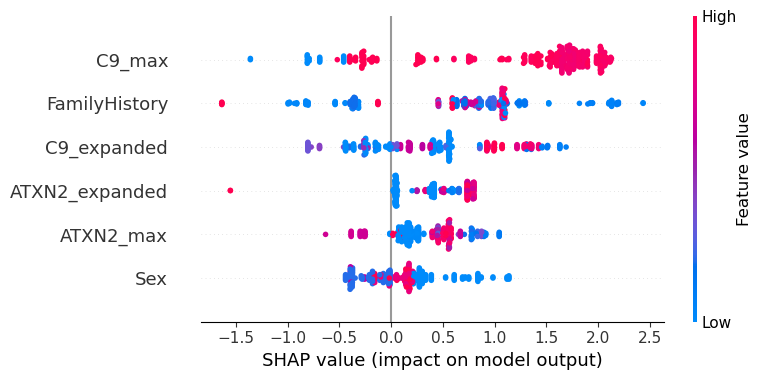

In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import shap

# 1) Load data (assuming CSV)
df = pd.read_csv(r"C:\Users\SNEHALATA ROUT\Downloads\collections.postmortem_tissue_core.rnaseq_metadata.csv")

# 2) Harmonize labels
df['Subject Group'] = df['Subject Group'].str.replace('Non[- ]Neurological Control','Control', regex=True)
# Create binary target (ALS vs Control/Others)
df['target'] = df['Subject Group'].apply(lambda x: 1 if ('ALS' in str(x) or 'MND' in str(x)) else 0)

# 3) Parse repeat-size fields
import re
def parse_repeat(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    # Missing tokens
    if re.match(r'^(N/A|NA|ND|UNKNOWN|\-9999)$', s, re.IGNORECASE):
        return np.nan
    # a/b format
    m = re.match(r'^(\d+)\s*/\s*(\d+)$', s)
    if m:
        a, b = int(m.group(1)), int(m.group(2))
        return float(max(a,b))
    # DD-MMM
    m = re.match(r'^(\d{1,2})-([A-Za-z]{3})$', s)
    if m:
        day, mon = int(m.group(1)), m.group(2)
        mnum = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
                "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}[mon]
        return float(max(day, mnum))
    # MMM-DD or MMM-YY
    m = re.match(r'^([A-Za-z]{3})-(\d{1,2})$', s)
    if m:
        mon, num = m.group(1), int(m.group(2))
        mnum = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
                "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}[mon]
        return float(max(mnum, num))
    # Numeric
    try:
        return float(s)
    except:
        return np.nan

df['C9_max'] = df['C 9 Repeat Size'].apply(parse_repeat)
df['ATXN2_max'] = df['Atxn 2 Repeat Size'].apply(parse_repeat)

# 4) Flag rows needing review
flags = []
for idx, val in df[['C 9 Repeat Size','Atxn 2 Repeat Size']].iterrows():
    for col in ['C 9 Repeat Size','Atxn 2 Repeat Size']:
        orig = val[col]
        parsed = parse_repeat(orig)
        if isinstance(parsed, float) and parsed > 100:
            flags.append((idx, col, orig, parsed))
        # Additional February check
        if isinstance(orig, str) and re.match(r'^[A-Za-z]{3}-\d{1,2}$', orig):
            mon, num = orig.split('-')
            if mon=='Feb' and int(num)>28:
                flags.append((idx, col, orig, parsed))


# 5) Derived features
df['Sex'] = df['Sex'].fillna('Unknown').astype(str)
df['FamilyHistory'] = df['Family History Of Als Ftd'].fillna('No').astype(str)
df['C9_expanded'] = df['C 9 Orf 72 Repeat Expansion'].fillna('No').map({'Yes':1,'No':0})
df['ATXN2_expanded'] = df['Atxn 2 Repeat Expansion'].fillna('No').map({'Yes':1,'No':0})
df['ATXN2_atrisk'] = (df['ATXN2_max'] >= 27).astype(int)
# Ancestry columns numeric
ancestry_cols = ['Pct African','Pct South Asian','Pct East Asian','Pct European','Pct Americas']
for c in ancestry_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

# 6) Prepare feature matrices
feature_sets = {
    'FULL': ['Sex','FamilyHistory','C9_expanded','ATXN2_expanded','C9_max','ATXN2_max'] + ancestry_cols,
    'NO-C9': ['Sex','FamilyHistory','ATXN2_expanded','ATXN2_max'] + ancestry_cols,
    'C9-ONLY': ['C9_expanded','C9_max','Sex'],
    'SPORADIC': ['Sex'] + ancestry_cols
}

# Helper to encode and return X, y
def build_XY(df, features):
    X = df[features].copy()
    for col in X.select_dtypes(include='object'):
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    # numeric impute
    X = X.fillna(X.median())
    return X.values, df['target'].values

# 7) Training and cross-validation
results = {}
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=123)
for name, feats in feature_sets.items():
    X, y = build_XY(df, feats)
    rocs, prs, brs = [], [], []
    for train_idx, test_idx in sgkf.split(X, y, groups=df['Site Specimen Collected'].values):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]
        scale = (len(ytr) - ytr.sum()) / ytr.sum()  # ratio neg:pos
        model = XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.03,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=scale, random_state=42,
                              eval_metric='logloss')
        model.fit(Xtr, ytr)
        proba = model.predict_proba(Xte)[:,1]
        rocs.append(roc_auc_score(yte, proba))
        prs.append(average_precision_score(yte, proba))
        brs.append(brier_score_loss(yte, proba))
    results[name] = (np.mean(rocs), np.mean(prs), np.mean(brs))
    print(f"{name}: ROC={np.mean(rocs):.3f}, PR={np.mean(prs):.3f}, Brier={np.mean(brs):.3f}")


# 9) SHAP analysis on final FULL model (last fold)
final_model = model  # from last fold above
X_train, X_test, y_train, y_test = Xtr, Xte, ytr, yte
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feature_sets['FULL'], show=False)

# 10) Calibration curve (optional example)
# from sklearn.calibration import calibration_curve
# prob_pos = final_model.predict_proba(X_test)[:,1]
# fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_pos, n_bins=10)
# (Plot fraction vs mean_predicted for reliability diagram)


In [44]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_score, n_boot=1000, seed=0):
    """
    Compute ROC-AUC mean and 95% CI via bootstrap.
    Inputs:
      - y_true: array-like of true binary labels (0/1).
      - y_score: array-like of predicted probabilities for label 1.
      - n_boot: number of bootstrap samples.
      - seed: random seed for reproducibility.
    Returns:
      (mean_auc, lower_ci, upper_ci).
    """
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), size=len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue  # skip invalid resample
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    if not aucs:
        raise ValueError("Insufficient class variation in bootstrap samples.")
    aucs = np.array(aucs)
    mean_auc = aucs.mean()
    ci_low, ci_high = np.percentile(aucs, [2.5, 97.5])
    return mean_auc, ci_low, ci_high
    print(f"ROC-AUC CI: {ci_low:.3f}-{ci_high:.3f}")

#Example usage (must compute y_prob first):
# model.fit(X_train, y_train)
# y_prob = model.predict_proba(X_test)[:,1]
# auc_mean, ci_low, ci_high = bootstrap_auc_ci(y_test, y_prob, n_boot=1000, seed=42)
 #print(f"ROC-AUC = {auc_mean:.3f} (95% CI {ci_low:.3f}-{ci_high:.3f})



1) FULL MODEL
Features: ['Sex', 'Family History Of Als Ftd', 'C 9 Orf 72 Repeat Expansion', 'Atxn 2 Repeat Expansion', 'C 9 Repeat Size', 'Atxn 2 Repeat Size', 'Pct African', 'Pct South Asian', 'Pct East Asian', 'Pct European', 'Pct Americas']
ROC-AUC: 0.755  (boot mean 0.755, 95% CI 0.723-0.786)
PR-AUC : 0.953   (boot mean 0.953, 95% CI 0.944-0.961)
Brier : 0.114 (boot mean 0.114, 95% CI 0.104-0.123)

2) NO-C9 MODEL
Features: ['Sex', 'Family History Of Als Ftd', 'Atxn 2 Repeat Expansion', 'Atxn 2 Repeat Size', 'Pct African', 'Pct South Asian', 'Pct East Asian', 'Pct European', 'Pct Americas']
ROC-AUC: 0.733  (boot mean 0.733, 95% CI 0.700-0.767)
PR-AUC : 0.947   (boot mean 0.947, 95% CI 0.936-0.956)
Brier : 0.119 (boot mean 0.119, 95% CI 0.109-0.129)

3) C9-ONLY MODEL
Features: ['C 9 Orf 72 Repeat Expansion', 'C 9 Repeat Size']
ROC-AUC: 0.640  (boot mean 0.640, 95% CI 0.608-0.669)
PR-AUC : 0.923   (boot mean 0.923, 95% CI 0.909-0.937)
Brier : 0.236 (boot mean 0.236, 95% CI 0.229-0.24

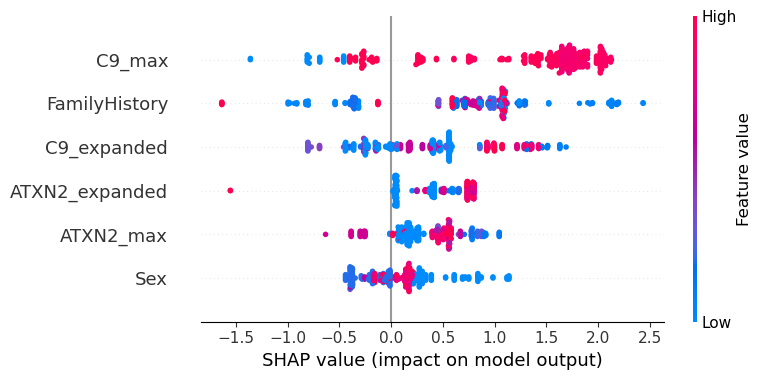

In [47]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import StratifiedGroupKFold
from xgboost import XGBClassifier

# =========================
# 0) TARGET + FILTER (primary analysis)
# =========================
df["target"] = df["Subject Group"].apply(lambda x: 1 if ("ALS" in str(x) or "MND" in str(x)) else 0)

# Optional but recommended for primary paper analysis:
# Keep only ALS Spectrum MND vs Non-Neurological Control
# (merge label variants first if needed)
# df = df[df["Subject Group"].isin(["ALS Spectrum MND", "Non-Neurological Control"])].copy()

# =========================
# 1) Feature sets (4 models)
# =========================
features_full = [
    "Sex",
    "Family History Of Als Ftd",
    "C 9 Orf 72 Repeat Expansion",
    "Atxn 2 Repeat Expansion",
    "C 9 Repeat Size",
    "Atxn 2 Repeat Size",
    "Pct African",
    "Pct South Asian",
    "Pct East Asian",
    "Pct European",
    "Pct Americas",
]

features_no_c9 = [f for f in features_full if f not in ["C 9 Orf 72 Repeat Expansion", "C 9 Repeat Size"]]
features_c9_only = ["C 9 Orf 72 Repeat Expansion", "C 9 Repeat Size"]
features_sporadic = ["Sex", "Pct African", "Pct South Asian", "Pct East Asian", "Pct European", "Pct Americas"]

# =========================
# 2) Repeat-size robust parsing (max allele)
# =========================
MONTH_MAP = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,"Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
MISSING_TOKENS = {"", "nan", "none", "unknown", "n/a", "n/d", "nd", "-9999"}

def parse_repeat_to_max(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s.lower() in MISSING_TOKENS:
        return np.nan

    # a/b
    if "/" in s:
        parts = s.split("/")
        if len(parts) == 2 and parts[0].strip().isdigit() and parts[1].strip().isdigit():
            a1, a2 = int(parts[0].strip()), int(parts[1].strip())
            return float(max(a1, a2))
        return np.nan

    # dd-MMM or MMM-dd
    if "-" in s:
        a, b = s.split("-", 1)
        a, b = a.strip(), b.strip()
        if a.isdigit() and b[:3] in MONTH_MAP:     # 07-Dec -> 7/12
            return float(max(int(a), MONTH_MAP[b[:3]]))
        if a[:3] in MONTH_MAP and b.isdigit():     # Dec-15 -> 12/15
            return float(max(MONTH_MAP[a[:3]], int(b)))

    # numeric
    try:
        return float(s)
    except:
        return np.nan

for col in ["C 9 Repeat Size", "Atxn 2 Repeat Size"]:
    if col in df.columns:
        df[col] = df[col].apply(parse_repeat_to_max)

# =========================
# 3) Build X matrix (encode categoricals + median impute)
# =========================
def make_matrix(df_in, feature_list):
    X_df = df_in[feature_list].copy()

    for c in X_df.columns:
        if not pd.api.types.is_numeric_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(str).fillna("missing")
            le = LabelEncoder()
            X_df[c] = le.fit_transform(X_df[c])

    for c in X_df.columns:
        X_df[c] = pd.to_numeric(X_df[c], errors="coerce")
        X_df[c] = X_df[c].fillna(X_df[c].median())

    X = X_df.values.astype(np.float32)
    y = df_in["target"].values.astype(int)
    return X, y

# =========================
# 4) XGBoost + OOF predictions (grouped CV)
# =========================
def get_model(scale_pos_weight):
    return XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

def oof_predict_groupcv(df_in, feature_list, group_col="Site Specimen Collected", n_splits=5):
    X, y = make_matrix(df_in, feature_list)
    groups = df_in[group_col].astype(str).fillna("missing").values

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_prob = np.full(len(y), np.nan, dtype=float)

    for tr_idx, te_idx in sgkf.split(X, y, groups):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        pos = y_tr.sum()
        neg = len(y_tr) - pos
        spw = (neg / pos) if pos > 0 else 1.0

        model = get_model(spw)
        model.fit(X_tr, y_tr)

        # THIS is the probability that you were missing outside the loop
        oof_prob[te_idx] = model.predict_proba(X_te)[:, 1]

    # drop any samples that never got predicted (rare but possible if groups too small)
    mask = ~np.isnan(oof_prob)
    return y[mask], oof_prob[mask]

# =========================
# 5) Bootstrap confidence intervals (no y_prob bug)
# =========================
def bootstrap_ci_metric(y_true, y_score, metric_fn, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        # skip invalid resample for ROC if only one class
        if metric_fn == roc_auc_score and len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], y_score[idx]))
    vals = np.array(vals)
    return float(np.mean(vals)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def report_model(name, df_in, feats):
    y_oof, p_oof = oof_predict_groupcv(df_in, feats)

    roc = roc_auc_score(y_oof, p_oof) if len(np.unique(y_oof)) == 2 else np.nan
    pr  = average_precision_score(y_oof, p_oof)
    brier = brier_score_loss(y_oof, p_oof)

    roc_m, roc_l, roc_u = bootstrap_ci_metric(y_oof, p_oof, roc_auc_score)
    pr_m,  pr_l,  pr_u  = bootstrap_ci_metric(y_oof, p_oof, average_precision_score)
    br_m,  br_l,  br_u  = bootstrap_ci_metric(y_oof, p_oof, brier_score_loss)

    print(f"\n{name}")
    print("Features:", feats)
    print(f"ROC-AUC: {roc:.3f}  (boot mean {roc_m:.3f}, 95% CI {roc_l:.3f}-{roc_u:.3f})")
    print(f"PR-AUC : {pr:.3f}   (boot mean {pr_m:.3f}, 95% CI {pr_l:.3f}-{pr_u:.3f})")
    print(f"Brier : {brier:.3f} (boot mean {br_m:.3f}, 95% CI {br_l:.3f}-{br_u:.3f})")

# =========================
# 6) STRICT SPORADIC variant (recommended)
# Train/evaluate only likely sporadic ALS + controls
# =========================
def make_strict_sporadic_subset(df_in):
    df2 = df_in.copy()

    # Keep ALS+controls only (recommended)
    # df2 = df2[df2["Subject Group"].isin(["ALS Spectrum MND", "Non-Neurological Control"])].copy()

    fh = df2["Family History Of Als Ftd"].astype(str).str.lower()
    c9 = df2["C 9 Orf 72 Repeat Expansion"].astype(str).str.lower()
    at = df2["Atxn 2 Repeat Expansion"].astype(str).str.lower()

    sporadic_mask = (
        (fh.isin(["no", "unknown", "nan"])) &
        (c9.isin(["no", "nan", "unknown"])) &
        (at.isin(["no", "nan", "unknown"]))
    )
    return df2[sporadic_mask].copy()

# =========================
# RUN ALL 4 + STRICT SPORADIC
# =========================
report_model("1) FULL MODEL", df, features_full)
report_model("2) NO-C9 MODEL", df, features_no_c9)
report_model("3) C9-ONLY MODEL", df, features_c9_only)
report_model("4) SPORADIC MODEL (features removed)", df, features_sporadic)

df_sp_strict = make_strict_sporadic_subset(df)
report_model("5) STRICT SPORADIC SUBSET + SPORADIC FEATURES", df_sp_strict, features_sporadic)
 #SHAP analysis on final FULL model (last fold)
final_model = model  # from last fold above
X_train, X_test, y_train, y_test = Xtr, Xte, ytr, yte
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feature_sets['FULL'], show=False)
